In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

FILE_PATH = '/content/drive/MyDrive/DVA_Project/data/interim/cleaned.csv'
df = pd.read_csv(FILE_PATH)

print(df.shape)
df.head()

(11971, 11)


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
print(df.dtypes)
print("\nMissing:\n", df.isnull().sum())

transaction_id       object
customer_id          object
category             object
item                 object
price_per_unit      float64
quantity            float64
total_spent         float64
payment_method       object
location             object
transaction_date     object
discount_applied       bool
dtype: object

Missing:
 transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64


In [5]:
num_cols = ['price_per_unit', 'quantity', 'total_spent']

df[num_cols].describe()

,price_per_unit,quantity,total_spent
count,11971.000000,11971.000000,11971.000000
mean,23.360872,5.536380,129.652577
std,10.741889,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


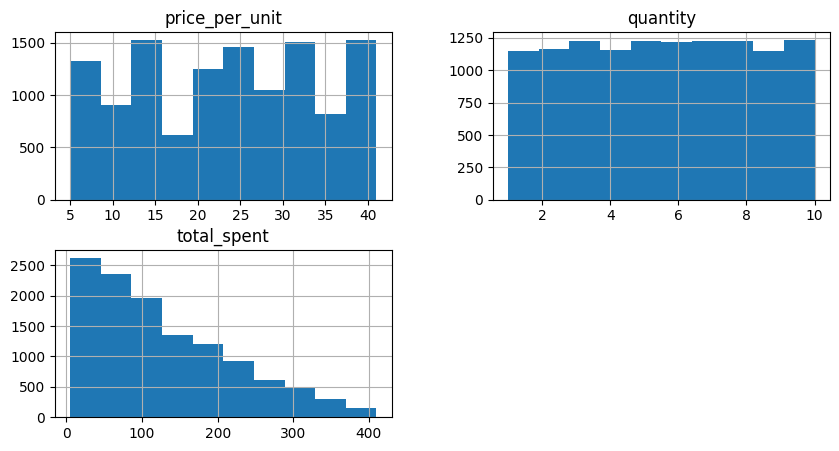

In [6]:
df[num_cols].hist(figsize=(10,5))
plt.show()

In [7]:
cat_cols = ['category', 'payment_method', 'location', 'discount_applied']

for col in cat_cols:
    print(df[col].value_counts())

category
Furniture                             1525
Electric Household Essentials         1516
Milk Products                         1513
Food                                  1507
Butchers                              1496
Beverages                             1496
Computers And Electric Accessories    1477
Patisserie                            1441
Name: count, dtype: int64
payment_method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64
location
Online      6068
In-Store    5903
Name: count, dtype: int64
discount_applied
False    7952
True     4019
Name: count, dtype: int64


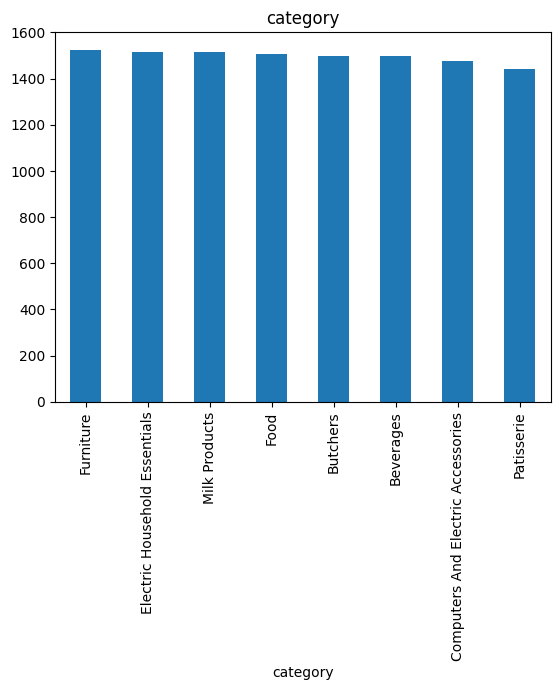

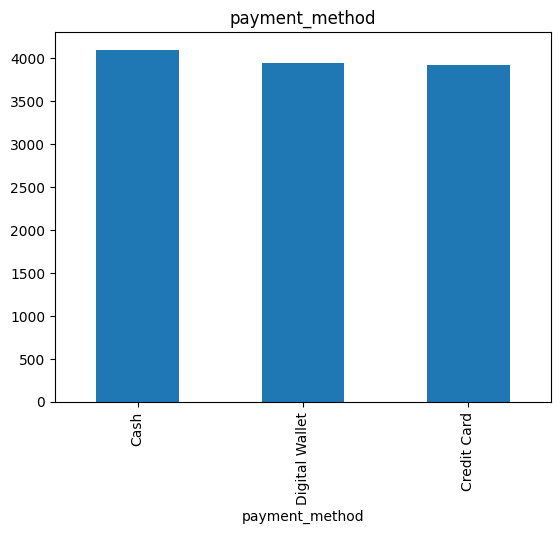

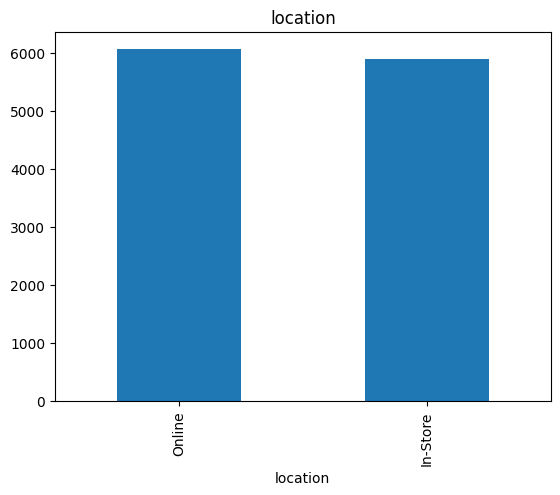

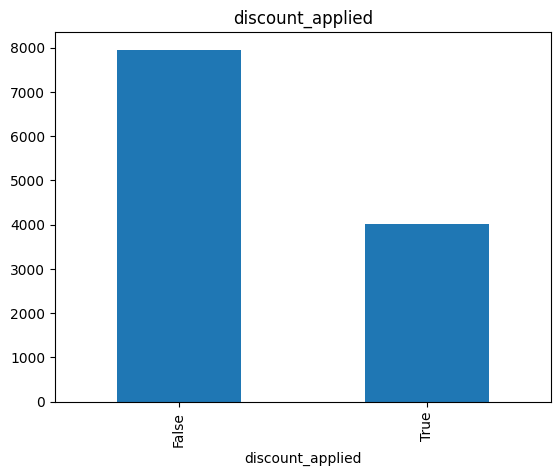

In [8]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

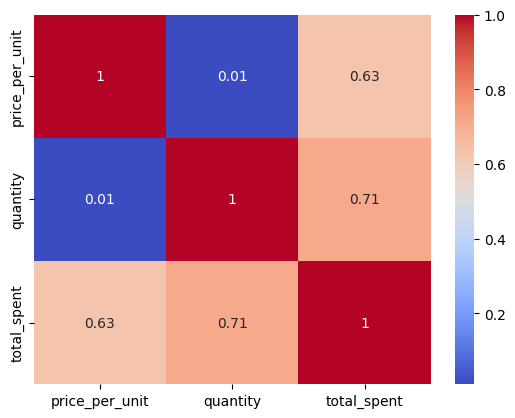

In [9]:
corr = df[['price_per_unit','quantity','total_spent']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

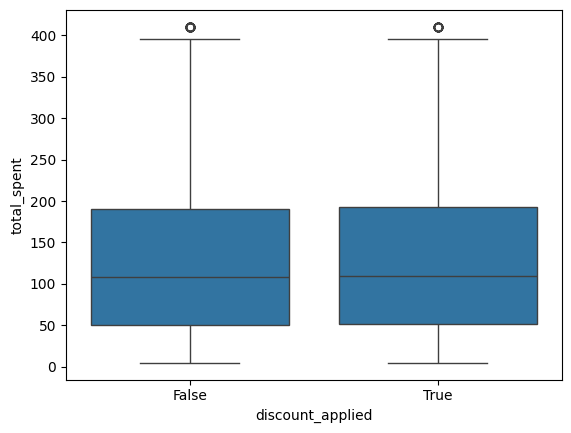

In [10]:
sns.boxplot(x='discount_applied', y='total_spent', data=df)
plt.show()

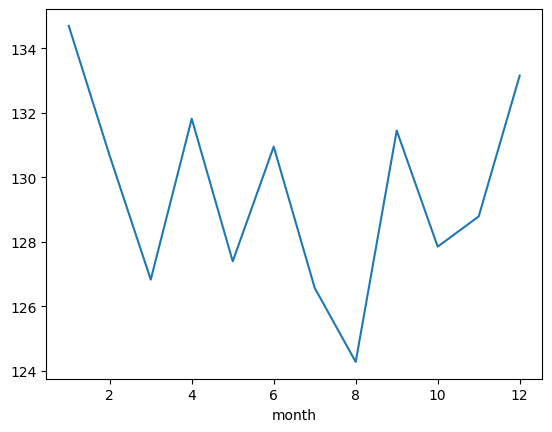

In [11]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month

df.groupby('month')['total_spent'].mean().plot()
plt.show()

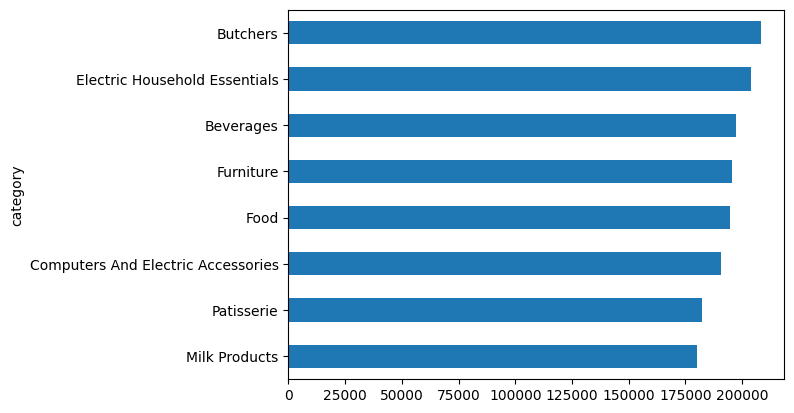

In [12]:
df.groupby('category')['total_spent'].sum().sort_values().plot(kind='barh')
plt.show()

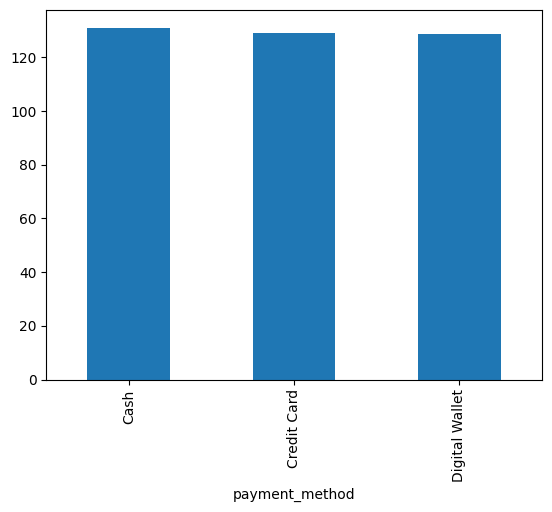

In [13]:
df.groupby('payment_method')['total_spent'].mean().plot(kind='bar')
plt.show()

In [14]:
df.to_csv('/content/drive/MyDrive/DVA_Project/data/interim/eda_ready.csv', index=False)